In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

bse = yf.Ticker("^BSESN")
data = bse.history(period="max")
print(data.head())

                                  Open         High          Low        Close  \
Date                                                                            
1997-07-01 00:00:00+05:30  4263.109863  4301.770020  4247.660156  4300.859863   
1997-07-02 00:00:00+05:30  4302.959961  4395.310059  4295.399902  4333.899902   
1997-07-03 00:00:00+05:30  4335.790039  4393.290039  4299.970215  4323.459961   
1997-07-04 00:00:00+05:30  4332.700195  4347.589844  4300.580078  4323.819824   
1997-07-07 00:00:00+05:30  4326.810059  4391.009766  4289.490234  4291.450195   

                           Volume  Dividends  Stock Splits  
Date                                                        
1997-07-01 00:00:00+05:30       0        0.0           0.0  
1997-07-02 00:00:00+05:30       0        0.0           0.0  
1997-07-03 00:00:00+05:30       0        0.0           0.0  
1997-07-04 00:00:00+05:30       0        0.0           0.0  
1997-07-07 00:00:00+05:30       0        0.0           0.0  


In [2]:
data = data.drop(columns=["Dividends", "Stock Splits"])
data.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-04-22 00:00:00+05:30,79019.343750,79031.031250,78442.296875,78516.492188,16900
2026-04-23 00:00:00+05:30,77983.656250,78178.539062,77574.179688,77664.000000,24900
2026-04-24 00:00:00+05:30,77483.796875,77710.820312,76403.867188,76664.210938,14100
2026-04-27 00:00:00+05:30,76856.046875,77420.039062,76754.203125,77303.632812,21200
2026-04-28 00:00:00+05:30,77094.789062,77493.531250,76973.539062,77375.023438,0


In [3]:
summary = data.describe()
print(summary)

               Open          High           Low         Close        Volume
count   7099.000000   7099.000000   7099.000000   7099.000000  7.099000e+03
mean   25858.838576  25999.033699  25680.131205  25838.703385  5.789896e+04
std    22924.020551  23015.246524  22812.210592  22915.564151  8.889506e+05
min     2621.889893   2682.590088   2594.870117   2600.120117  0.000000e+00
25%     5840.729980   5893.199951   5774.314941   5822.794922  6.500000e+03
50%    18450.070312  18565.560547  18280.699219  18439.650391  1.140000e+04
75%    36057.033203  36239.439453  35826.250000  35995.384766  1.820000e+04
max    86065.921875  86159.023438  85577.820312  85836.117188  3.181510e+07


In [4]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7099 entries, 1997-07-01 00:00:00+05:30 to 2026-04-28 00:00:00+05:30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    7099 non-null   float64
 1   High    7099 non-null   float64
 2   Low     7099 non-null   float64
 3   Close   7099 non-null   float64
 4   Volume  7099 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 332.8 KB


In [6]:
data['50ma'] = data['Close'].rolling(window=50).mean()
data['200ma'] = data['Close'].rolling(window=200).mean()

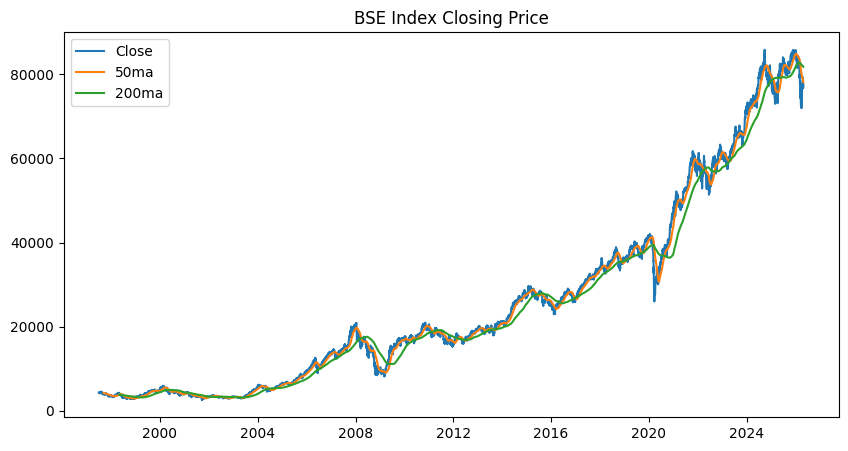

In [8]:
plt.figure(figsize=(10,5))
plt.plot(data["Close"])
plt.plot(data["50ma"])
plt.plot(data["200ma"])
plt.title("BSE Index Closing Price")
plt.legend(['Close', '50ma', '200ma'])
plt.show()

In [9]:
data['DailyReturn'] = data['Close'].pct_change()
data['DailyReturn'].describe()

count    7098.000000
mean        0.000508
std         0.014166
min        -0.131526
25%        -0.006143
50%         0.000782
75%         0.007455
max         0.173393
Name: DailyReturn, dtype: float64

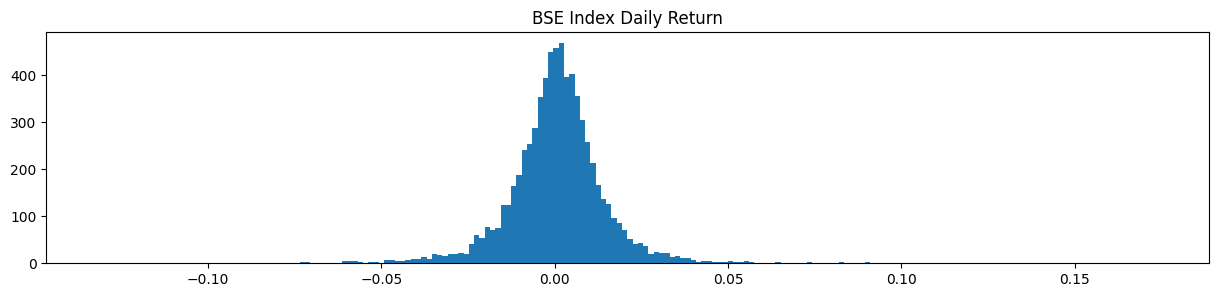

In [11]:
plt.figure(figsize=(15, 3))
plt.title('BSE Index Daily Return')
data['DailyReturn'].hist(bins=200, grid=False)
plt.show()

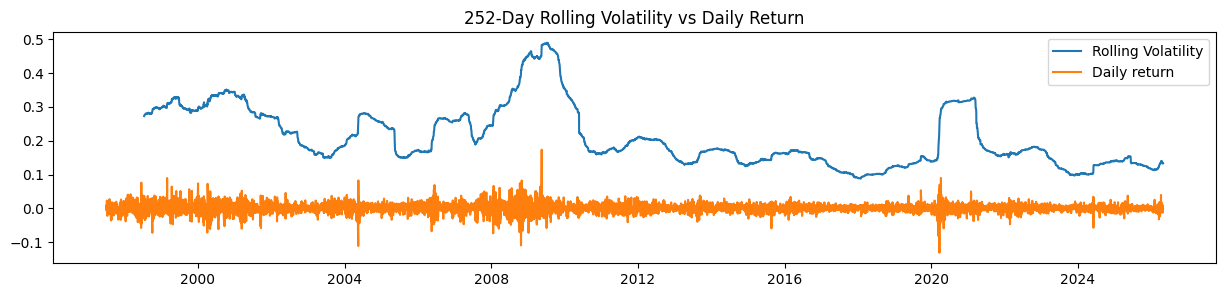

In [27]:
vol = data["DailyReturn"].rolling(window=252).std()*(252 ** 0.5) # annualizes volatility
dreturn = data['DailyReturn']
plt.figure(figsize=(15, 3))
plt.plot(vol)
plt.plot(dreturn)
plt.legend(['Rolling Volatility', 'Daily return'])
plt.title("252-Day Rolling Volatility vs Daily Return")
plt.show()

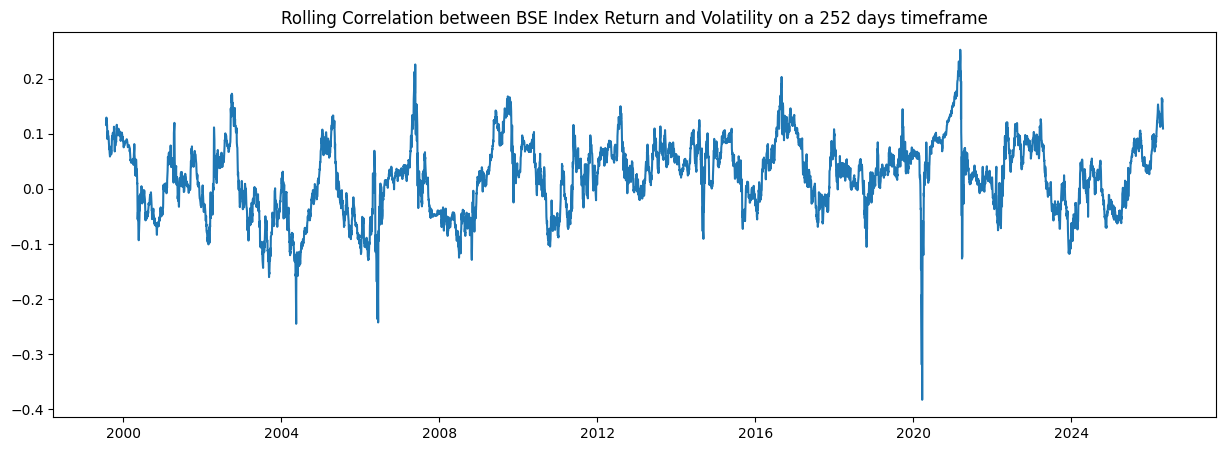

In [28]:
data['volatility'] = data['DailyReturn'].rolling(window=252).std() * (252 ** 0.5)
data['corr252'] = data['DailyReturn'].rolling(window=252).corr(data['volatility'])
plt.figure(figsize=(15, 5))
plt.title('Rolling Correlation between BSE Index Return and Volatility on a 252 days timeframe')
plt.plot(data['corr252'])
plt.show()